<h1 style="text-align:center; color:green; font-size:48px;">
OEMOF TUTORIAL
</h1>

### Support functions

In [1]:
# Levelized Cost of Heat

def LCOH(invest_cost, operation_cost, heat_produced, revenue=0, i=0.05, n=20):
    pvf = ((1 + i) ** n - 1) / ((1 + i) ** n * i)

    return (invest_cost + pvf * (operation_cost - revenue)) / (
        pvf * heat_produced
    )
    
# Equivalent Periodic Cost

def epc(invest_cost, i=0.05, n=20):
    af = (i * (1 + i) ** n) / ((1 + i) ** n - 1)

    return invest_cost * af

# Import libraries

In [2]:
import os
import warnings
import logging
import pandas as pd
import matplotlib.pyplot as plt
from oemof.solph import (Bus, EnergySystem, Flow, Model, create_time_index, processing, Investment, NonConvex)
from oemof.solph.components import (Sink, Source, Converter, GenericStorage)
from oemof.solph import EnergySystem
from oemof.solph import views
import oemof.solph as solph

# Example

<img src="Example_OEMOF.png" width="40%">

## 1.1 Create the energy system

In [3]:
# read the input data file
filename = r"OEMOF_files/Example_1.csv"
data = pd.read_csv(filename)

# specifying the solver
solver = "cbc"
solver_verbose = False

# Create energy system
datetimeindex = pd.date_range(
    start='2022-01-01 00:00',
    periods=len(data),  # 8760 matches your data
    freq='h'
)
energysystem = EnergySystem(timeindex=datetimeindex, infer_last_interval=False)

# Add components to the energy system

# Buses - internal_elec_bus representing the electricity generated only by both CHPs
electrical_bus = Bus(label="electrical_bus") # Electricity bus (external grid)
thermal_bus = Bus(label="thermal_bus") # Heating bus
gas_bus = Bus(label="gas_bus") # Natural gas bus
biomass_bus = Bus(label="biomass_bus") # Biomass fuel bus
internal_elec_bus = Bus(label="internal_elec_bus") # Electricity from internal generation (NG and biomass CHPs)

energysystem.add(electrical_bus, thermal_bus, gas_bus, biomass_bus, internal_elec_bus)

# Thermal demand (sink)
load_kW = data["thermal_demand"]
peak = load_kW.max()
energysystem.add(
    Sink(
        label="thermal_demand",
        inputs={thermal_bus: Flow(
            nominal_value=peak,
            fix=data["thermal_demand"] / peak
        )},
    )
)


# Excess electricity sink (only external grid)
energysystem.add(
    Sink(
        label="excess_electricity",
        inputs={electrical_bus: Flow(
            variable_costs=data["electricity_price"]/1000 * -1,
            nominal_value=1e10          
        )}
    )
)

# Excess thermal sink (thermal surplus)
energysystem.add(
    Sink(
        label="excess_thermal",
        inputs={thermal_bus: Flow(
            nominal_value=1e10,       
            variable_costs=0       # INCREASE to penalize the excess heat
        )}
    )
)


# Sink for excess internal electricity (if the CHPs produce more than needed)
energysystem.add(
    Sink(
        label="excess_internal_electricity",
        inputs={internal_elec_bus: Flow(  
            nominal_value=1e10
        )}
    )
)

# Gas source with cost from gas
energysystem.add(
    Source(label="natural_gas",outputs={gas_bus: Flow()}) # costs defined in the converters
)

# Grid electricity source
energysystem.add(
    Source(label="electricity_grid",outputs={electrical_bus: Flow(variable_costs=data["electricity_price"]/1000)})
)

# Biomass source with cost
biomass_cost_per_mwh = data["biomass_price"] / 4.167
biomass_cost_per_kwh = biomass_cost_per_mwh / 1000

energysystem.add(
    Source(
        label="biomass_source",
        outputs={
            biomass_bus: Flow() # costs defined in the converters
        },
    )
)

# Investment (capex) assumptions in €/kW thermal for each converter (references in pptx)
capex_kw_th = {
    "biomass_chp": 2200,   
    "chp": 1200,          
    "heat_pump": 1400,      
    "electric_boiler": 250, 
    "solar_collector": 300 
}

# O&M costs as variable_costs on thermal output (references in pptx)
om_variable_costs = {
    'biomass_chp': 0.00877551,      # 3.5% × 2200 / 8760h  
    'chp': 0.01770000,              # $0.0177/kWh_th
    'heat_pump': 0.00239726,        # 1.5% × 1400 / 8760h
    'electric_boiler': 0.00028539,  # 1.0% × 250 / 8760h
    'solar_collector': 0.00051429   # 1.5% x 300 / 8760h
}


# Biomass CHP
energysystem.add(
    Converter(
        label="biomass_chp",
        inputs={biomass_bus: 
                Flow(variable_costs=biomass_cost_per_kwh
                     )},
        outputs={
            internal_elec_bus: Flow(),
            thermal_bus: Flow(
                investment=Investment(
                    ep_costs=epc(capex_kw_th["biomass_chp"]),  # 2200 €/kW_th
                    minimum=100, 
                    maximum=800
                ),
                variable_costs=om_variable_costs['biomass_chp']  # O&M 
            )
        },
        conversion_factors={internal_elec_bus: 0.25, thermal_bus: 0.50}
    )
)


# Gas CHP
energysystem.add(
    Converter(
        label="chp",
        inputs={gas_bus: Flow(
            variable_costs=data["gas_price"] / 1000
        )},
        outputs={
            internal_elec_bus: Flow(),
            thermal_bus: Flow(
                investment=Investment(
                    ep_costs=epc(capex_kw_th["chp"]),
                    minimum=100,
                    maximum=800
                ),
                variable_costs=om_variable_costs['chp']  # O&M

            )
        },
        conversion_factors={internal_elec_bus: 0.33, thermal_bus: 0.50}
    )
)

# Heat pump
energysystem.add(
    Converter(
        label="heat_pump",
        inputs={internal_elec_bus: Flow(), electrical_bus: Flow()},
        outputs={
            thermal_bus: Flow(
                investment=Investment(
                    ep_costs=epc(capex_kw_th["heat_pump"]),
                    minimum=100,
                    maximum=500
                ),
                variable_costs=om_variable_costs['heat_pump']  # O&M

            )
        },
        conversion_factors={thermal_bus: 3.5}
    )
)

# Electric boiler
energysystem.add(
    Converter(
        label="electric_boiler",
        inputs={internal_elec_bus: Flow(), electrical_bus: Flow()},
        outputs={
            thermal_bus: Flow(
                investment=Investment(
                    ep_costs=epc(capex_kw_th["electric_boiler"]),
                    minimum=100,
                    maximum=800
                ),
                variable_costs=om_variable_costs['electric_boiler']  # O&M

                
            )
        },
        conversion_factors={thermal_bus: 0.99}
    )
)


/opt/anaconda3/envs/env_P2/lib/python3.9/site-packages/oemof/solph/flows/_flow.py:163: FutureWarning: For backward compatibility, the option investment overwrites the option nominal_value. Both options cannot be set at the same time.
  warn(msg, FutureWarning)


### Adding the solar thermal collector to the system

In [4]:
# Loadind irradiance and ambient temperature data
SolarCollector_inputs = pd.read_csv('OEMOF_files/SolarCollector_inputs.csv')
# Extract the columns for global and diffuse horizontal irradiance     
SolarCollector_inputs['Global'] = pd.to_numeric(SolarCollector_inputs['Global'], errors='coerce')

global_horizontal_W_m2 = SolarCollector_inputs['Global']
collector_aperture_area = 1000
collector_efficiency = 0.73

thermal_output = (global_horizontal_W_m2 * collector_aperture_area * collector_efficiency)/1000

In [5]:
thermal_profile = pd.Series(thermal_output.values, index=datetimeindex)

# Align profile length with model intervals (infer_last_interval=False → n-1 intervals)
aligned_profile = thermal_profile.iloc[: len(energysystem.timeindex) - 1]
nominal_value = aligned_profile.max()

# Normalize the fixed profile to [0,1]
fix_profile = aligned_profile / nominal_value

energysystem.add(Source(
    label='solar_collector',
    outputs={
        thermal_bus: Flow(
            nominal_value=nominal_value,
            fix=fix_profile.values,  # normalized fixed flow profile as numpy array
            variable_costs=om_variable_costs['solar_collector']
        )
    }
))

## 1.2 Build and solve model

In [6]:
model = Model(energysystem)


logging.info("Solving the optimization problem.")
model.solve(
    solver='cbc',
    solve_kwargs={"tee": True},
    cmdline_options={"ratioGap": "0.02"}
)

'''
This returns a dictionary containing time series and scalar results for all components (buses, converters, sources, etc.).
Or view results for a specific node (for example, a bus).
'''

# Process results
energysystem.results["main"] = processing.results(model)
energysystem.results["meta"] = processing.meta_results(model)

# Save results to file
output_file = os.path.join(os.getcwd(), "Outputs/results.oemof")

energysystem.dump(os.getcwd(), "Outputs/results.oemof")

logging.info("Results have been dumped.")

/opt/anaconda3/envs/env_P2/lib/python3.9/site-packages/oemof/solph/_plumbing.py:82: FutureWarning: Sequence longer than needed (8760 items instead of 8759). This will be trated as an error in the future.
  warnings.warn(


Welcome to the CBC MILP Solver 
Version: 2.10.12 
Build Date: Sep  3 2024 

command line - /opt/anaconda3/envs/env_P2/bin/cbc -ratioGap 0.02 -printingOptions all -import /var/folders/7p/sw30zsrs46z7txczcvfyfspm0000gn/T/tmp7340k82m.pyomo.lp -stat=1 -solve -solu /var/folders/7p/sw30zsrs46z7txczcvfyfspm0000gn/T/tmp7340k82m.pyomo.soln (default strategy 1)
ratioGap was changed from 0 to 0.02
Option for printingOptions changed from normal to all
Presolve 52554 (-96353) rows, 35040 (-122631) columns and 140144 (-227742) elements
Statistics for presolved model


Problem has 52554 rows, 35040 columns (35040 with objective) and 140144 elements
Column breakdown:
35036 of type 0.0->inf, 0 of type 0.0->up, 0 of type lo->inf, 
4 of type lo->up, 0 of type free, 0 of type fixed, 
0 of type -inf->0.0, 0 of type -inf->up, 0 of type 0.0->1.0 
Row breakdown:
0 of type E 0.0, 0 of type E 1.0, 0 of type E -1.0, 
0 of type E other, 0 of type G 0.0, 0 of type G 1.0, 
0 of type G other, 35036 of type L 0.0, 0 

/opt/anaconda3/envs/env_P2/lib/python3.9/site-packages/oemof/network/energy_system.py:256: FutureWarning: Parameter 'dpath' will be removed in a future version. You can give the directory as part of the filename and set 'consider_dpath' to False to suppress this waring.
  warnings.warn(


## 1.3 Results

In [7]:
energysystem.results

results = energysystem.results["main"]

# get all variables of a specific component/bus
thermal_results = views.node(results, "thermal_bus")
storage_results = views.node(results, "storage")
electrical_results = views.node(results, "electrical_bus")
internal_elec_results = views.node(results, "internal_elec_bus")

### Analyse thermal node

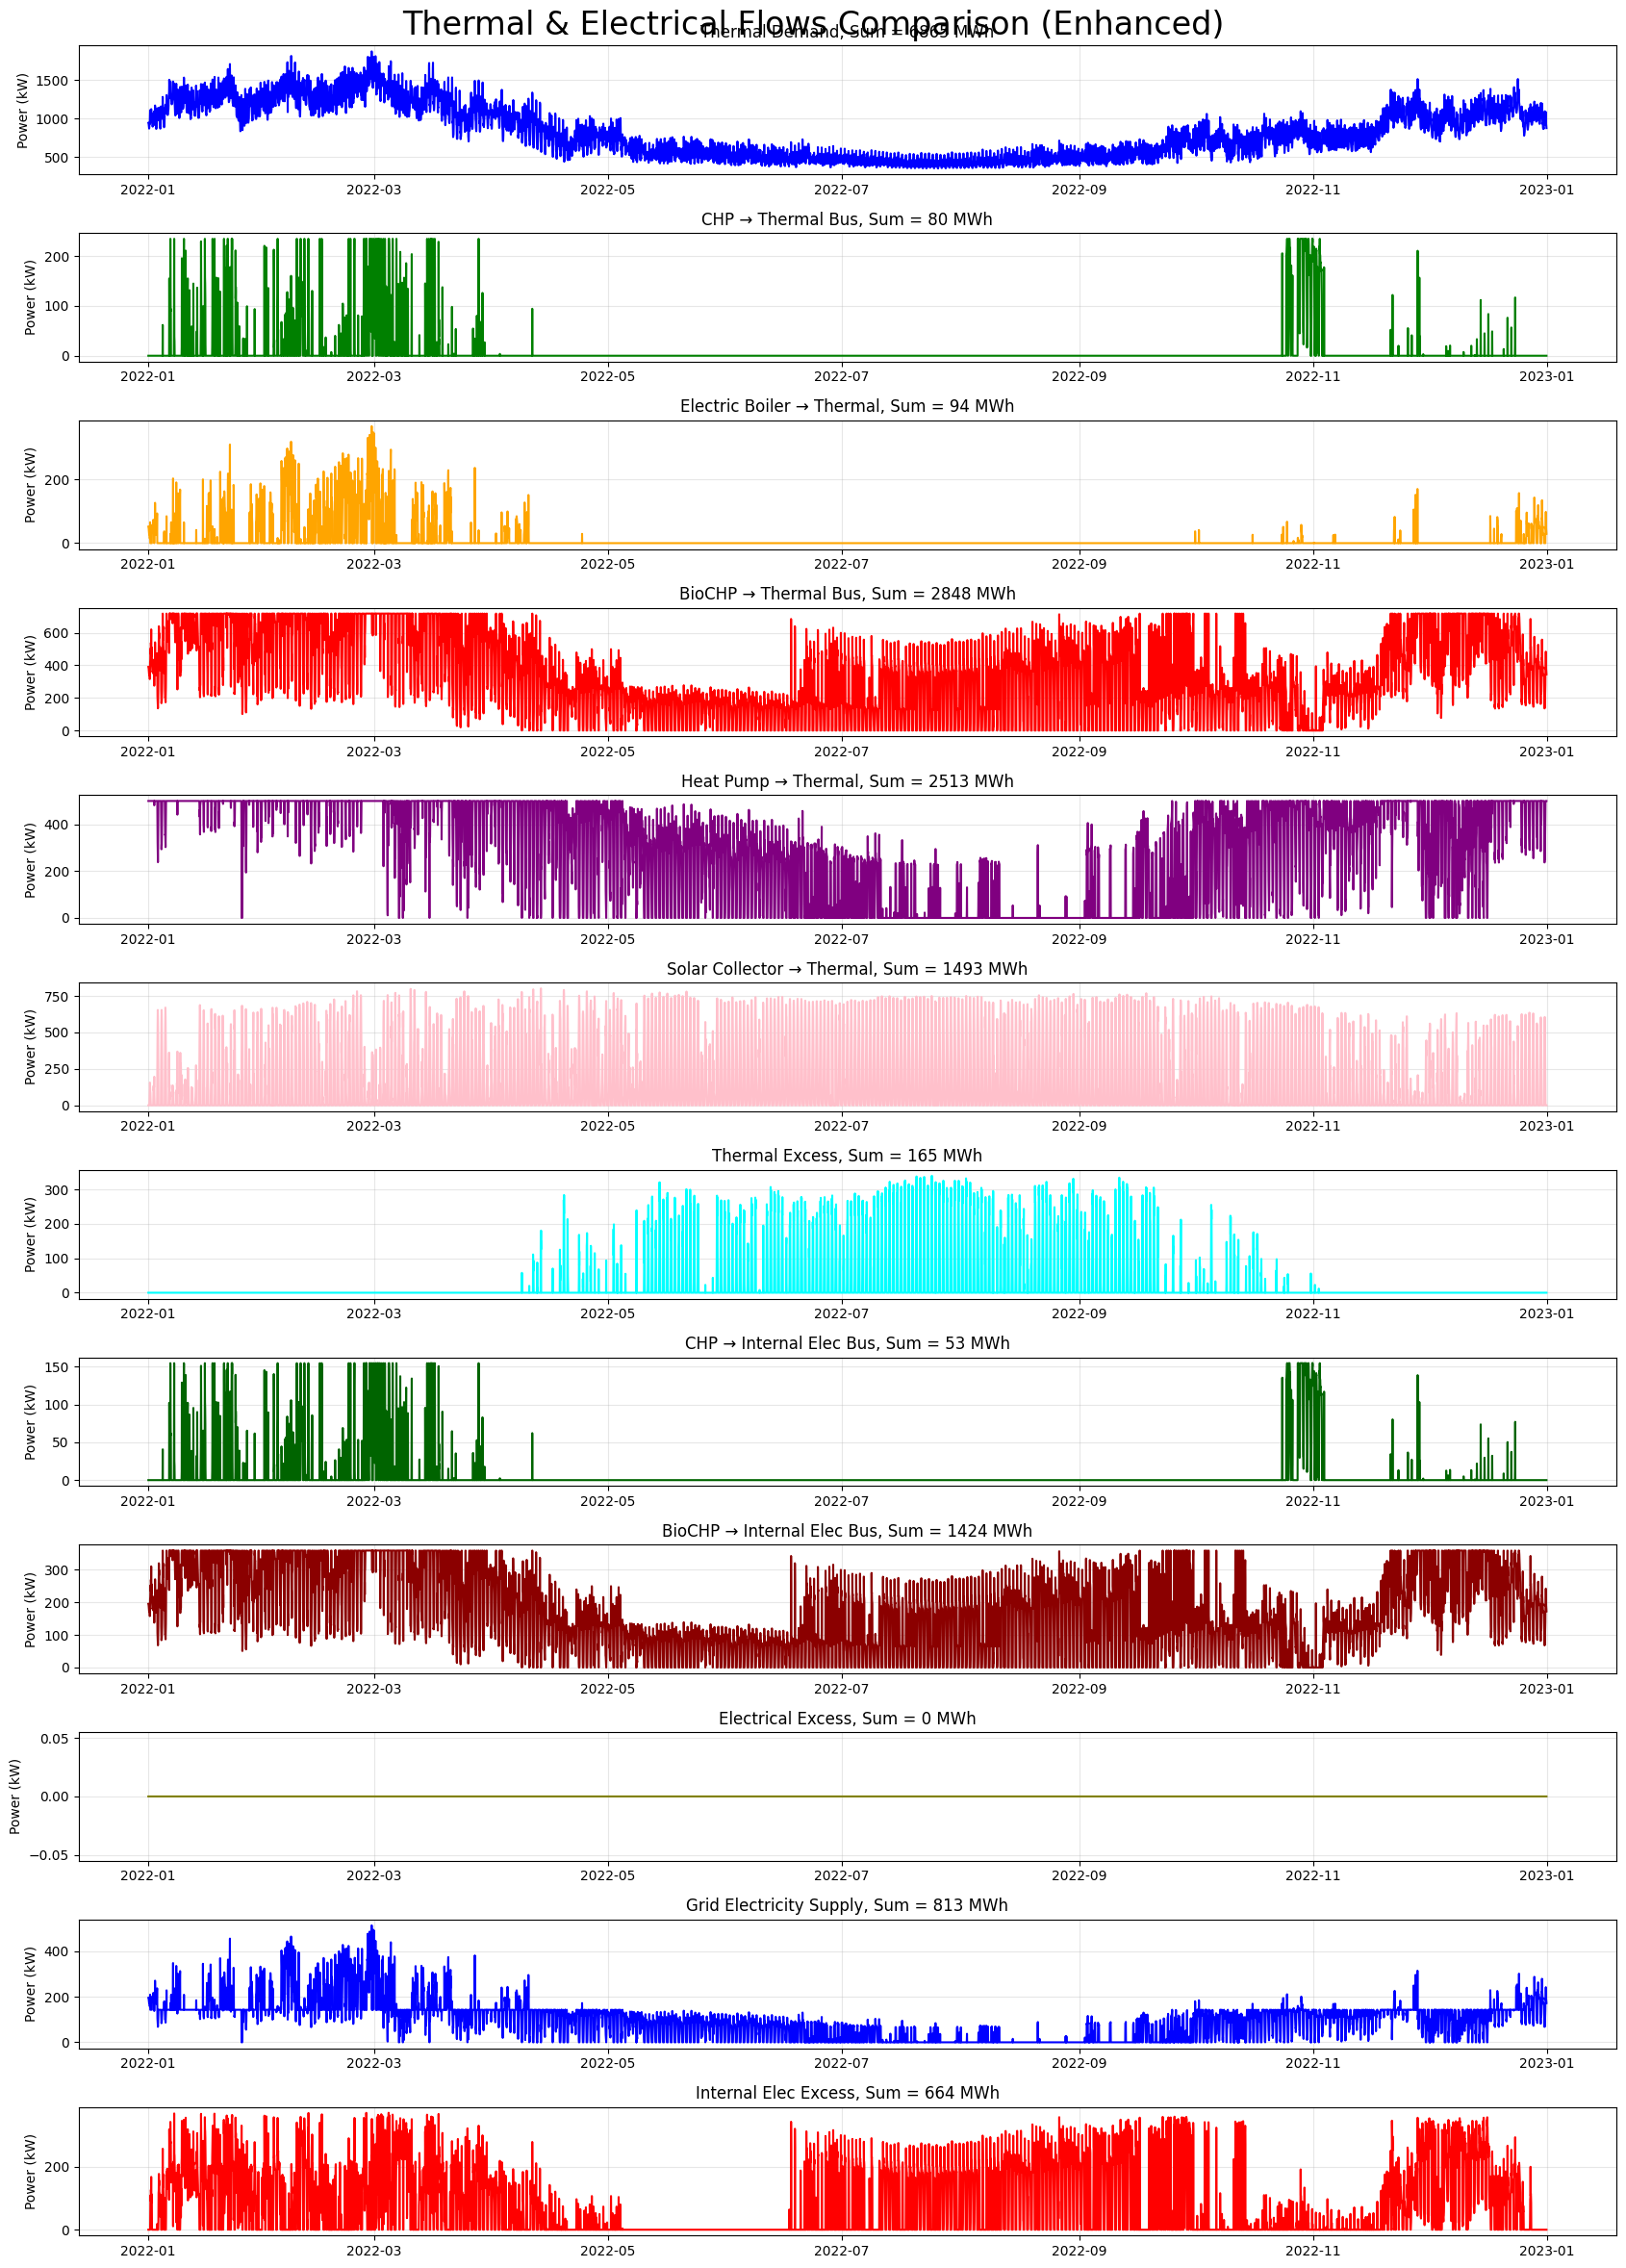

In [8]:
# Thermal sums (existing)
Sum_th_demand = thermal_results["sequences"][(('thermal_bus', 'thermal_demand'), 'flow')].sum()
Sum_th_prod_chp = thermal_results["sequences"][(('chp', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_boiler = thermal_results["sequences"][(('electric_boiler', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_biochp = thermal_results["sequences"][(('biomass_chp', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_hp = thermal_results["sequences"][(('heat_pump', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_sth = thermal_results["sequences"][(('solar_collector', 'thermal_bus'), 'flow')].sum()
Sum_th_excess = thermal_results["sequences"][(('thermal_bus','excess_thermal'), 'flow')].sum()

# Electrical sums (existing + NEW electrical outputs from CHP/BioCHP)
Sum_excess_elec = electrical_results["sequences"][(('electrical_bus', 'excess_electricity'), 'flow')].sum()
Sum_el_grid_prod = electrical_results["sequences"][(('electricity_grid', 'electrical_bus'), 'flow')].sum()
Sum_el_excess_int = internal_elec_results["sequences"][(('internal_elec_bus', 'excess_internal_electricity'), 'flow')].sum()

# NEW: CHP electrical production to internal bus
Sum_el_prod_chp = internal_elec_results["sequences"][(('chp', 'internal_elec_bus'), 'flow')].sum()
# NEW: Biomass CHP electrical production to internal bus
Sum_el_prod_biochp = internal_elec_results["sequences"][(('biomass_chp', 'internal_elec_bus'), 'flow')].sum()

# Updated 12-subplot figure
fig, axs = plt.subplots(12, 1, figsize=(17, 24))
fig.suptitle('Thermal & Electrical Flows Comparison (Enhanced)', fontsize=24)

# Thermal flows (0-6, unchanged)
axs[0].plot(thermal_results["sequences"][(('thermal_bus', 'thermal_demand'), 'flow')], 'blue')
axs[0].set_title(f'Thermal Demand, Sum = {int(Sum_th_demand/1000)} MWh')

axs[1].plot(thermal_results["sequences"][(('chp', 'thermal_bus'), 'flow')], 'green')
axs[1].set_title(f'CHP → Thermal Bus, Sum = {int(Sum_th_prod_chp/1000)} MWh')

axs[2].plot(thermal_results["sequences"][(('electric_boiler', 'thermal_bus'), 'flow')], 'orange')
axs[2].set_title(f'Electric Boiler → Thermal, Sum = {int(Sum_th_prod_boiler/1000)} MWh')

axs[3].plot(thermal_results["sequences"][(('biomass_chp', 'thermal_bus'), 'flow')], 'red')
axs[3].set_title(f'BioCHP → Thermal Bus, Sum = {int(Sum_th_prod_biochp/1000)} MWh')

axs[4].plot(thermal_results["sequences"][(('heat_pump', 'thermal_bus'), 'flow')], 'purple')
axs[4].set_title(f'Heat Pump → Thermal, Sum = {int(Sum_th_prod_hp/1000)} MWh')

axs[5].plot(thermal_results["sequences"][(('solar_collector', 'thermal_bus'), 'flow')], 'pink')
axs[5].set_title(f'Solar Collector → Thermal, Sum = {int(Sum_th_prod_sth/1000)} MWh')

axs[6].plot(thermal_results["sequences"][(('thermal_bus','excess_thermal'), 'flow')], 'cyan')
axs[6].set_title(f'Thermal Excess, Sum = {int(Sum_th_excess/1000)} MWh')

axs[7].plot(internal_elec_results["sequences"][(('chp', 'internal_elec_bus'), 'flow')], 'darkgreen')
axs[7].set_title(f'CHP → Internal Elec Bus, Sum = {int(Sum_el_prod_chp/1000)} MWh')

axs[8].plot(internal_elec_results["sequences"][(('biomass_chp', 'internal_elec_bus'), 'flow')], 'darkred')
axs[8].set_title(f'BioCHP → Internal Elec Bus, Sum = {int(Sum_el_prod_biochp/1000)} MWh')

axs[9].plot(electrical_results["sequences"][(('electrical_bus', 'excess_electricity'), 'flow')], 'olive')
axs[9].set_title(f'Electrical Excess, Sum = {int(Sum_excess_elec/1000)} MWh')

axs[10].plot(electrical_results["sequences"][(('electricity_grid', 'electrical_bus'), 'flow')], 'blue')
axs[10].set_title(f'Grid Electricity Supply, Sum = {int(Sum_el_grid_prod/1000)} MWh')

axs[11].plot(internal_elec_results["sequences"][(('internal_elec_bus', 'excess_internal_electricity'), 'flow')], 'red')
axs[11].set_title(f'Internal Elec Excess, Sum = {int(Sum_el_excess_int/1000)} MWh')

# Format all subplots
for ax in axs:
    ax.set_ylabel('Power (kW)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Let's visualize the capacity and CAPEX of the technologies used (not the CSP since it's constant)

In [9]:
from oemof.solph import processing

res = processing.results(model)
res_str = processing.convert_keys_to_strings(res)  
print(list(res_str.keys())[:10])


def get_invest_capacity(label_from, label_to="thermal_bus"):
    flow = res_str[(label_from, label_to)]
    scal = flow["scalars"]
    invest_row = scal[scal.index.to_series().str.contains("invest")]
    invest_value = float(invest_row.iloc[0])   # kW_th
    return invest_value

for comp in ["biomass_chp", "chp", "heat_pump", "electric_boiler"]:
    cap = get_invest_capacity(comp)                     # kW_th
    capex_unit = capex_kw_th[comp]                     # €/kW_th
    total_capex = cap * capex_unit                     # €
    print(f"{comp}: capacity = {cap:.2f} kW_th, CAPEX = {total_capex:,.2f} €")

CAPEX_solar=nominal_value*capex_kw_th["solar_collector"]
print(f"solar_collector: capacity = {nominal_value:.2f} kW_th, CAPEX = {CAPEX_solar:,.2f} €")

[('biomass_bus', 'biomass_chp'), ('biomass_chp', 'internal_elec_bus'), ('biomass_chp', 'thermal_bus'), ('biomass_source', 'biomass_bus'), ('chp', 'internal_elec_bus'), ('chp', 'thermal_bus'), ('electric_boiler', 'thermal_bus'), ('electrical_bus', 'electric_boiler'), ('electrical_bus', 'excess_electricity'), ('electrical_bus', 'heat_pump')]
biomass_chp: capacity = 717.46 kW_th, CAPEX = 1,578,412.00 €
chp: capacity = 234.55 kW_th, CAPEX = 281,454.71 €
heat_pump: capacity = 500.00 kW_th, CAPEX = 700,000.00 €
electric_boiler: capacity = 366.97 kW_th, CAPEX = 91,741.55 €
solar_collector: capacity = 802.09 kW_th, CAPEX = 240,626.25 €


Generating an Excel file for future analysis

In [10]:
!pip install openpyxl

grid_supply = electrical_results["sequences"][(('electricity_grid', 'electrical_bus'), 'flow')]
internal_excess = internal_elec_results["sequences"][(('internal_elec_bus', 'excess_internal_electricity'), 'flow')]

# Per-timestep view of grid supply vs internal excess with difference
flows_comparison = pd.DataFrame(
    {
        'Grid Electricity Supply (kW)': grid_supply.values,
        'Internal Electricity Excess (kW)': internal_excess.values,
    },
    index=grid_supply.index,
)
flows_comparison['Grid minus Internal (kW)'] = (
    flows_comparison['Grid Electricity Supply (kW)']
    - flows_comparison['Internal Electricity Excess (kW)']
)

flows_comparison.to_excel('Outputs/electricity_flows_comparison.xlsx', 
                          sheet_name='Grid_vs_Internal', 
                          index=True)


## Answers to the questions

In order to compare the results with the ones obtained in the step 4, the thermal results are exported 

In [11]:
# Export all results for comparison in STEP_4
import os
from pathlib import Path

# Get the current directory (STEP_3)
current_dir = Path.cwd()
# Navigate to STEP_4 directory
step4_dir = current_dir.parent / "STEP_4"

# Create Outputs directory in STEP_4 if it doesn't exist
output_dir = step4_dir / "Outputs"
output_dir.mkdir(parents=True, exist_ok=True)

# Export all sequences from all bus views
all_flows_export = {}

# Thermal bus flows
for key, value in thermal_results["sequences"].items():
    col_name = f"{key[0][0]}_{key[0][1]}_{key[1]}"
    all_flows_export[col_name] = value

# Electrical bus flows
for key, value in electrical_results["sequences"].items():
    col_name = f"{key[0][0]}_{key[0][1]}_{key[1]}"
    all_flows_export[col_name] = value

# Internal electrical bus flows
for key, value in internal_elec_results["sequences"].items():
    col_name = f"{key[0][0]}_{key[0][1]}_{key[1]}"
    all_flows_export[col_name] = value

# Gas bus flows (if available)
gas_bus_res = views.node(results, "gas_bus")
for key, value in gas_bus_res["sequences"].items():
    col_name = f"{key[0][0]}_{key[0][1]}_{key[1]}"
    all_flows_export[col_name] = value

# Biomass bus flows (if available)
biomass_bus_res = views.node(results, "biomass_bus")
for key, value in biomass_bus_res["sequences"].items():
    col_name = f"{key[0][0]}_{key[0][1]}_{key[1]}"
    all_flows_export[col_name] = value

# Create DataFrame and export
# Get index from first sequence
first_key = list(all_flows_export.keys())[0]
results_df = pd.DataFrame(all_flows_export, index=all_flows_export[first_key].index)
results_df.to_csv(output_dir / "STEP_3_results.csv", index=True)

print(f"All results exported to: {output_dir / 'STEP_3_results.csv'}")
print(f"Exported {len(all_flows_export)} flow sequences")


All results exported to: /Users/michelangeloinze/Desktop/Optmization of Energy Networks/Project_2/LOCAL/STEP_4/Outputs/STEP_3_results.csv
Exported 20 flow sequences


 ### Which generating units are supplying the majority of the heat demand over the simulation period? How is the load distributed among the units?


In [12]:
# Summary: which units supply most of the heat demand?

thermal_flows = {
    "NG CHP": thermal_results["sequences"][(("chp", "thermal_bus"), "flow")].sum(),
    "Biomass CHP": thermal_results["sequences"][(("biomass_chp", "thermal_bus"), "flow")].sum(),
    "Heat pump": thermal_results["sequences"][(("heat_pump", "thermal_bus"), "flow")].sum(),
    "Electric boiler": thermal_results["sequences"][(("electric_boiler", "thermal_bus"), "flow")].sum(),
    "Solar collector": thermal_results["sequences"][(("solar_collector", "thermal_bus"), "flow")].sum(),
}

heat_demand = thermal_results["sequences"][(("thermal_bus", "thermal_demand"), "flow")].sum()
excess_heat = thermal_results["sequences"][(("thermal_bus", "excess_thermal"), "flow")].sum()

total_prod = sum(thermal_flows.values())

# The delivered solar heat equals solar production minus excess
solar_delivered = max(thermal_flows["Solar collector"] - excess_heat, 0)

summary_df = (
    pd.Series(thermal_flows)
    .to_frame("kWh_produced")
    .assign(
        MWh_produced=lambda df: df["kWh_produced"] / 1000,
        MWh_supplied=lambda df: df["kWh_produced"] / 1000,
    )
)
summary_df.loc["Solar collector", "MWh_supplied"] = solar_delivered / 1000

summary_df["% of total prod"] = (summary_df["MWh_produced"] / (total_prod / 1000) * 100).round(1)
summary_df["% of demand (supplied)"] = (summary_df["MWh_supplied"] / (heat_demand / 1000) * 100).round(1)
summary_df = summary_df.sort_values("MWh_produced", ascending=False)

print("Total production (MWh):", round(total_prod / 1000, 1))
print("Total heat demand (MWh):", round(heat_demand / 1000, 1))
print("Excess heat sent to sink (assumed from solar) (MWh):", round(excess_heat / 1000, 1))
print("\nHeat by unit (sorted by produced):")
print(summary_df[["MWh_produced", "MWh_supplied", "% of total prod", "% of demand (supplied)"]])

# Main contributor by supplied heat to demand
top_unit, top_mwh = summary_df.sort_values("MWh_supplied", ascending=False).iloc[0][[0,1]].name, summary_df.sort_values("MWh_supplied", ascending=False).iloc[0].MWh_supplied
print(f"\nMain contributor to demand: {top_unit} with ~{top_mwh:.1f} MWh supplied")



Total production (MWh): 7031.3
Total heat demand (MWh): 6865.5
Excess heat sent to sink (assumed from solar) (MWh): 165.9

Heat by unit (sorted by produced):
                 MWh_produced  MWh_supplied  % of total prod  \
Biomass CHP       2848.869471   2848.869471             40.5   
Heat pump         2513.684167   2513.684167             35.7   
Solar collector   1493.790612   1327.902663             21.2   
Electric boiler     94.062508     94.062508              1.3   
NG CHP              80.934521     80.934521              1.2   

                 % of demand (supplied)  
Biomass CHP                        41.5  
Heat pump                          36.6  
Solar collector                    19.3  
Electric boiler                     1.4  
NG CHP                              1.2  

Main contributor to demand: Biomass CHP with ~2848.9 MWh supplied


/var/folders/7p/sw30zsrs46z7txczcvfyfspm0000gn/T/ipykernel_12647/3442870272.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  top_unit, top_mwh = summary_df.sort_values("MWh_supplied", ascending=False).iloc[0][[0,1]].name, summary_df.sort_values("MWh_supplied", ascending=False).iloc[0].MWh_supplied


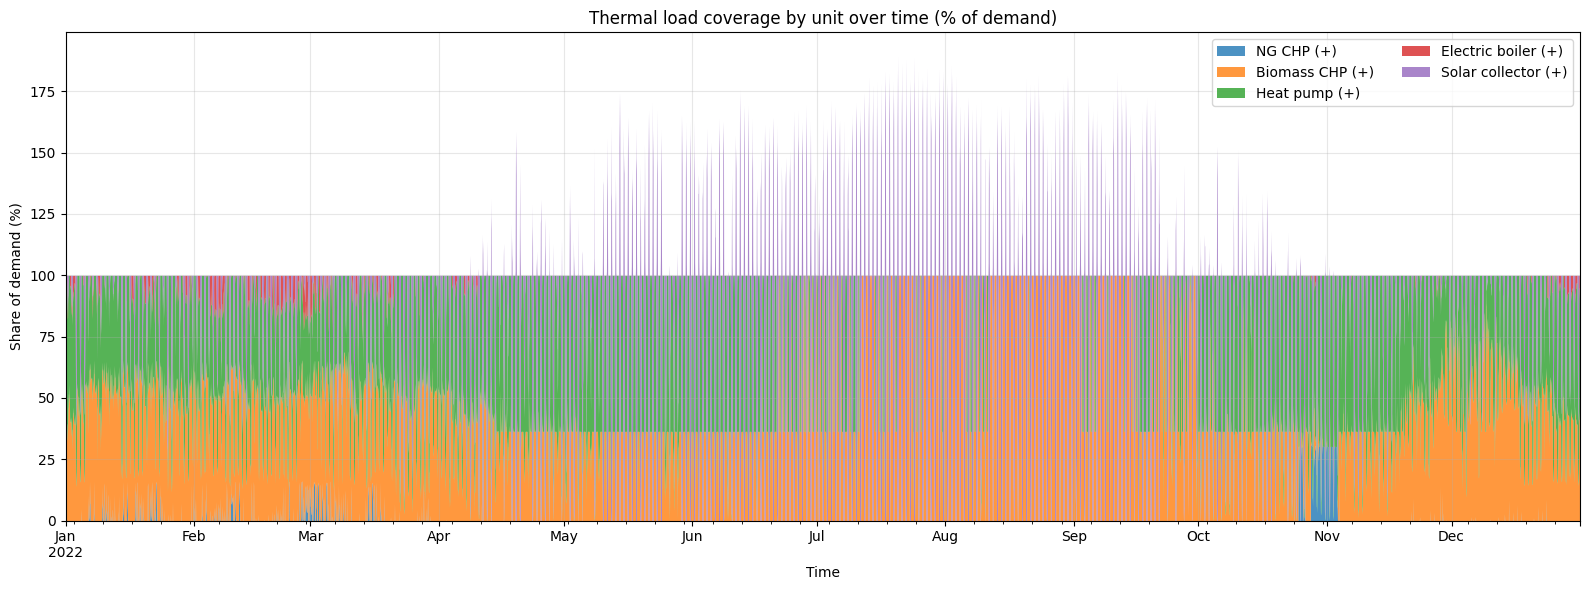

In [13]:
# How the thermal load is distributed among units over time (stacked area, %)

flows_ts = pd.DataFrame({
    "NG CHP": thermal_results["sequences"][(("chp", "thermal_bus"), "flow")],
    "Biomass CHP": thermal_results["sequences"][(("biomass_chp", "thermal_bus"), "flow")],
    "Heat pump": thermal_results["sequences"][(("heat_pump", "thermal_bus"), "flow")],
    "Electric boiler": thermal_results["sequences"][(("electric_boiler", "thermal_bus"), "flow")],
    "Solar collector": thermal_results["sequences"][(("solar_collector", "thermal_bus"), "flow")],
})

demand_ts = thermal_results["sequences"][(("thermal_bus", "thermal_demand"), "flow")]

# Compute percentage share per timestep; avoid div-by-zero
pct_ts = flows_ts.div(demand_ts.replace(0, pd.NA), axis=0) * 100
pct_ts = pct_ts.fillna(0)

pct_pos = pct_ts.clip(lower=0)

pct_pos.columns = [f"{c} (+)" for c in pct_pos.columns]

# Combine back into one DataFrame for plotting
pct_stacked = pd.concat([pct_pos], axis=1)

ax = pct_stacked.plot.area(figsize=(16, 6), linewidth=0, alpha=0.8)
plt.title("Thermal load coverage by unit over time (% of demand)")
plt.ylabel("Share of demand (%)")
plt.xlabel("Time")
plt.legend(loc="upper right", ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Are there periods when any of the generating units reach their maximum defined capacity? If yes, which units, and during what times?

In [14]:
# Thermal nominal capacities (kW) from the model definitions or derived
nominal_caps = {
    "Heat pump": get_invest_capacity("heat_pump"),
    "Electric boiler": get_invest_capacity("electric_boiler"),
    "Biomass CHP": get_invest_capacity("biomass_chp"),
    "NG CHP": get_invest_capacity("chp"),
    "Solar collector": nominal_value,
}

# Mapping to sequence keys
seq_keys = {
    "Heat pump": (("heat_pump", "thermal_bus"), "flow"),
    "Electric boiler": (("electric_boiler", "thermal_bus"), "flow"),
    "Biomass CHP": (("biomass_chp", "thermal_bus"), "flow"),
    "NG CHP": (("chp", "thermal_bus"), "flow"),
    "Solar collector": (("solar_collector", "thermal_bus"), "flow"),
}

maxed_info = {}
tolerance = 1e-6
for unit, cap in nominal_caps.items():
    s = thermal_results["sequences"][seq_keys[unit]]
    hits = s[s >= cap - tolerance]
    # find longest consecutive streak (hourly index) - optional plot
    if hits.empty:
        longest = 0
        first_time = None
    else:
        diffs = hits.index.to_series().diff().dt.total_seconds().div(3600).fillna(1)
        streak_id = (diffs != 1).cumsum()
        longest = int(hits.groupby(streak_id).size().max())
        first_time = hits.index[0]
    maxed_info[unit] = {
        "hours_at_cap": len(hits),
        "first_time": first_time,
        "longest_consecutive_hours": longest,
        "cap_kW": cap,
    }

print("Units vs nominal capacity (thermal output):")
for unit, info in maxed_info.items():
    if info["hours_at_cap"] > 0:
        print(
            f"- {unit} (cap {info['cap_kW']:.1f} kW): {info['hours_at_cap']} hours at cap, "
            f"longest run {info['longest_consecutive_hours']}h, first at {info['first_time']}"
        )
    else:
        print(f"- {unit} (cap {info['cap_kW']:.1f} kW): never reached max capacity")



Units vs nominal capacity (thermal output):
- Heat pump (cap 500.0 kW): 2825 hours at cap, longest run 139h, first at 2022-01-01 00:00:00
- Electric boiler (cap 367.0 kW): 1 hours at cap, longest run 1h, first at 2022-02-28 07:00:00
- Biomass CHP (cap 717.5 kW): 1066 hours at cap, longest run 41h, first at 2022-01-04 18:00:00
- NG CHP (cap 234.5 kW): 117 hours at cap, longest run 16h, first at 2022-01-06 18:00:00
- Solar collector (cap 802.1 kW): 1 hours at cap, longest run 1h, first at 2022-04-13 11:00:00


### What are the total operational costs for each unit, and which unit contributes most to system costs?

The code above prices grid power only after crediting internal CHP generation:
- Start from flows_comparison["Grid minus Internal (kW)"], which already nets grid supply against internal electricity (e.g., CHP output).
- Clip negatives to zero so any surplus internal generation fully offsets grid use and accrues no charge.
- Align the electricity price series to the same timestep index.
- Multiply the positive net imports by the matching €/kWh price each timestep and sum to get total grid electricity cost.

This was necessary after analysing how the model isn't capable of receiving energy from two buses simultaneously (i.e. when internal electricity production from the CHPs is not enough to fullfil the demand) and so it takes everything from the grid. 

In the case when the internal electriciy is higher than the demand, a feed-in mechanism of the excess internal electricity production is not considered in this analysis. Because of that, the costs below are only related to the generation side of the system.

Moreover, the optimization model is believed to do not perform a "smart" optimization. Infact, it optimize the generation based on the prices of the fuels, but not considering the internally generated electricity when it's lower than the demand, and so taking it all from the grid, the costs result higher compared to a real situation. A possible solution would be to have a storage system which connecte both grid and internal electricity and acting as a buffer, since the sinks cannot have a bus connected in output in oemof.

In [15]:
# Operational costs by unit (variable costs only)

# Cost series (€/kWh)
gas_cost = data["gas_price"] / 1000
biomass_cost = (data["biomass_price"] / 4.167) / 1000
elec_price = data["electricity_price"] / 1000

# Flows (kW) via bus views
biomass_bus_res = views.node(results, "biomass_bus")
gas_bus_res = views.node(results, "gas_bus")
elec_bus_res = views.node(results, "electrical_bus")

flow_gas_to_chp = gas_bus_res["sequences"][(("gas_bus", "chp"), "flow")]
flow_biomass_to_biochp = biomass_bus_res["sequences"][(("biomass_bus", "biomass_chp"), "flow")]

# Use net grid import (positive only) from the earlier comparison table
net_grid = flows_comparison["Grid minus Internal (kW)"]
net_grid_import = net_grid.clip(lower=0)

# Align electricity price to the same index by position; avoid NaNs from mismatched indices
price_series = pd.Series(elec_price.values, index=net_grid_import.index)

grid_cost = (net_grid_import * price_series).sum()

fuel_costs = {
    "NG CHP (fuel)": (flow_gas_to_chp * gas_cost.values).sum(),
    "Biomass CHP (fuel)": (flow_biomass_to_biochp * biomass_cost.values).sum(),
    "Grid electricity": grid_cost,
    "Heat pump": 0.0,
    "Electric boiler": 0.0,
    "Solar collector": 0.0,
}

# O&M
hours_year = 8760
components = ["biomass_chp", "chp", "heat_pump", "electric_boiler", "solar_collector"]

# Get thermal flows per component (kW_h)
thermal_flows = {}
for comp in components:
    try:
        thermal_flow = views.node(results, comp)["sequences"][((comp, "thermal_bus"), "flow")]
        thermal_flows[comp] = thermal_flow
    except KeyError:
        thermal_flows[comp] = pd.Series(0.0, index=net_grid.index)

om_costs = {}
for comp in components:
    flow_kwh = thermal_flows[comp].sum()  # Total kWh_th produced
    om_rate = om_variable_costs[comp]     # €/kWh_th/h
    om_total = flow_kwh * om_rate         # Total €
    om_costs[comp.replace("_", " ").title()] = om_total

# Total OPEX
total_opex = {}

# Mapping fuel to O&M
fuel_to_om = {
    "NG CHP (fuel)": "Chp",
    "Biomass CHP (fuel)": "Biomass Chp",
    "Grid electricity": None,
    "Heat pump": "Heat Pump",
    "Electric boiler": "Electric Boiler",
    "Solar collector": "Solar Collector"
}

for tech in fuel_costs.keys():
    om_key = fuel_to_om[tech]
    if om_key is None:
        total_opex[tech] = fuel_costs[tech]
    else:
        total_opex[tech] = fuel_costs[tech] + om_costs.get(om_key, 0.0)

# Plotting tables
print("\n" + "="*60)
print("FUEL COSTS (EUR)")
print("="*60)
fuel_series = pd.Series(fuel_costs).sort_values(ascending=False)
print(fuel_series.round(0))

print("\n" + "="*60)
print("O&M COSTS (EUR)")
print("="*60)
om_series = pd.Series(om_costs).sort_values(ascending=False)
print(om_series.round(0))

print("\n" + "="*60)
print("TOTAL OPEX (Fuel + O&M) (EUR)")
print("="*60)
opex_series = pd.Series(total_opex).sort_values(ascending=False)
print(opex_series.round(0))

print(f"\nTotal variable cost (Fuel only): {fuel_series.sum():.0f} EUR")
print(f"Total O&M cost: {om_series.sum():.0f} EUR")
print(f"TOTAL OPEX: {opex_series.sum():.0f} EUR")

main_fuel = fuel_series.idxmax()
main_om = om_series.idxmax()
print(f"\nMain fuel contributor: {main_fuel} ({fuel_series.max():.0f} EUR)")
print(f"Main O&M contributor: {main_om} ({om_series.max():.0f} EUR)")



FUEL COSTS (EUR)
Biomass CHP (fuel)    246123.0
Grid electricity       84863.0
NG CHP (fuel)          12859.0
Heat pump                  0.0
Electric boiler            0.0
Solar collector            0.0
dtype: float64

O&M COSTS (EUR)
Biomass Chp        25000.0
Heat Pump           6026.0
Chp                 1433.0
Solar Collector      768.0
Electric Boiler       27.0
dtype: float64

TOTAL OPEX (Fuel + O&M) (EUR)
Biomass CHP (fuel)    271123.0
Grid electricity       84863.0
NG CHP (fuel)          14291.0
Heat pump               6026.0
Solar collector          768.0
Electric boiler           27.0
dtype: float64

Total variable cost (Fuel only): 343845 EUR
Total O&M cost: 33254 EUR
TOTAL OPEX: 377099 EUR

Main fuel contributor: Biomass CHP (fuel) (246123 EUR)
Main O&M contributor: Biomass Chp (25000 EUR)
